# plot points

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch.nn as nn
from scipy.io import loadmat
import scipy.sparse as sp
from scipy.spatial import cKDTree, distance
from scipy.linalg import solve, lstsq,lu_factor, lu_solve
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, splu
import matplotlib.pyplot as plt
from math import pi
import math

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(18.2574)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sigmoid(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    # nn.init.uniform_(m.bias, -np.pi, np.pi)
                    nn.init.uniform_(m.bias, -0, 0)

def dphi_wrt_y_1d_batch(phi_net, y, X):
    """
    1D Parameters
    ----------
    y : (n_j,1) or (n_j,)
    X : (K,1) or (K,)
    
    Returns
    -------
    phi_vals : (n_j, K)
    dphi_dy  : (n_j, K)
    d2phi_dy2: (n_j, K)
    """
    # -------- reshape --------
    y = torch.tensor(y, dtype=torch.float64, device=device).view(-1,1)   # (n_j,1)
    X = torch.tensor(X, dtype=torch.float64, device=device).view(1,-1)   # (1,K)

    # -------- pairwise diff --------
    r = torch.abs(y - X)                   # (n_j, K)
    r.requires_grad_(True)

    # -------- forward --------
    phi_vals = phi_net(r)         # (n_j, K)

    # -------- φ'(r) --------
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True
    )[0]   # (n_j, K)

    # -------- φ''(r) --------
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False
    )[0]   # (n_j, K)

    return (
        phi_vals.detach().cpu().numpy(),
        dphi_dr.detach().cpu().numpy(),
        d2phi_dr2.detach().cpu().numpy()
    )


def rfm_fd_solve_heat(kap, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg):
    """
    X:  (N,1)   source points
    Yin: (M1,1) interior points
    Yb:  (M2,1) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    W_ide = np.zeros((M, K))
    W_lap = np.zeros((M, K))
    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin, t) if callable(f_func) else f_func # (M1,NT)
    g_val = g_func(Yb, t) if callable(g_func) else g_func  # (2, NT)
    u0 = u0_func(Y) if callable(u0_func) else u0_func      # (M,1)

    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))
        A = np.zeros((K,K))
        y = Y[i,:] # (1,)
        idx_local = idx[i,:]   # (K,)
        Z = X[idx_local]       # (K,1)
        dist_ZZ = np.abs(Z - Z.T)      # (K,K) 
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, dx_phi, d2x_phi = dphi_wrt_y_1d_batch(Phi, y, Z) # (1,K)
        ## RHS_lap, RHS_ide
        RHS_lap = d2x_phi.T
        RHS_ide = phi_xj.T
        ## W_ide, W_lap
        A  =  Phi_jj  + reg * np.eye(K) # (K,K)

        w_ide = np.linalg.solve(A,RHS_ide).reshape(-1,) # (K,)
        W_ide[i,:] = w_ide
        w_lap = np.linalg.solve(A,RHS_lap).reshape(-1,) # (K,)
        W_lap[i,:] = w_lap
        if i < M1 :
            LBDF1[i,idx_local] = (w_ide - kap * tau * w_lap)
            LBDF2[i,idx_local] = (3 * w_ide - 2 * kap * tau * w_lap)
        else:
            LBDF1[i,idx_local] = w_ide
            LBDF2[i,idx_local] = w_ide
        LI[i,idx_local] = w_ide
    
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:,1:2] = LI @ alpha_1
        # U[:M1,1:2] = LI[:M1, :] @ alpha_1
        # U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            # alpha_2 = spsolve(LBDF2,RHS)[:,None]
            alpha_2 = LU.solve(RHS)
            U[:,i+1:i+2] = LI @ alpha_2
            alpha_0 = alpha_1
            alpha_1 = alpha_2

    else:
        print("M $\neq$ N. Please use QR.")
    return U,LBDF1,LBDF2,LI


def poly1D(x,order):  # (nj,1) -> (nj,order+1)
    if x.ndim == 1:
        x = x[:,None]
    return np.concatenate([x**k for k in range(order+1)], axis=1)

def lap_poly1D(x,order): # (nj,1) -> (nj,order+1)
        Norder = order + 1
        out = np.zeros((len(x), Norder))
        for k in range(2, order+1):
            out[:, k] = k*(k-1)*x**(k-2)
        return out

def rfm_fd_poly_solve_heat(kap, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order):
    """
    X:  (N,1)   source points
    Yin: (M1,1) interior points
    Yb:  (M2,1) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = order + 1 # number of polynomial basis in 1D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)
    # Construct sparse L matrix
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    LBDF2 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin, t) if callable(f_func) else f_func # (M1,NT)
    g_val = g_func(Yb, t) if callable(g_func) else g_func  # (2, NT)
    u0 = u0_func(Y) if callable(u0_func) else u0_func      # (M,1)

    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (1,)
        idx_local = idx[i,:]   # (K,)
        Z = X[idx_local]       # (K,1)
        dist_ZZ = np.abs(Z - Z.T)      # (K,K) 
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, dx_phi, d2x_phi = dphi_wrt_y_1d_batch(Phi, y, Z) # (1,K)
        ## AP
        P = poly1D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+Norder)
        AP[K:,:-Norder] = P.T # (Norder,K)
        AP = AP + reg * np.eye(K+Norder)
        LU = lu_factor(AP)
        ## w_ide, w_lap
        p_y = poly1D(y, order) # (1,Norder)
        RHS_ide[:K,0] = phi_xj.reshape(-1,)
        RHS_ide[K:,0] = p_y.reshape(-1,)
        w_ide = lu_solve(LU, RHS_ide).T # (1,K+Norder)
        RHS_lap[:K,0] = d2x_phi.reshape(-1,)
        RHS_lap[K:,0] = lap_poly1D(y,order).reshape(-1,)
        w_lap = lu_solve(LU, RHS_lap).T # (1,K+Noder)
        if i < M1 :
            LBDF1[i,idx_local] = (w_ide[0,:K] - kap * tau * w_lap[0,:K])
            LBDF2[i,idx_local] = (3 * w_ide[0,:K] - 2* kap * tau * w_lap[0,:K])
        else:
            LBDF1[i,idx_local] = w_ide[0,:K]
            LBDF2[i,idx_local] = w_ide[0,:K]
        LI[i,idx_local] = w_ide[0,:K]
        
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)


    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]  # (M,1)
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M is not equal to N. Please use QR.")
        
    return U,LBDF1,LBDF2,LI

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

cond(LI) = 1.000000000706335
cond(LBDF1) = 1.220920633176283
cond(LBDF2) = 3.250543859857535
p = 3; L infity error in u_rfmfd: 5.168e-03
p = 3; Relative L2 error in u_rfmfd: 5.023e-03


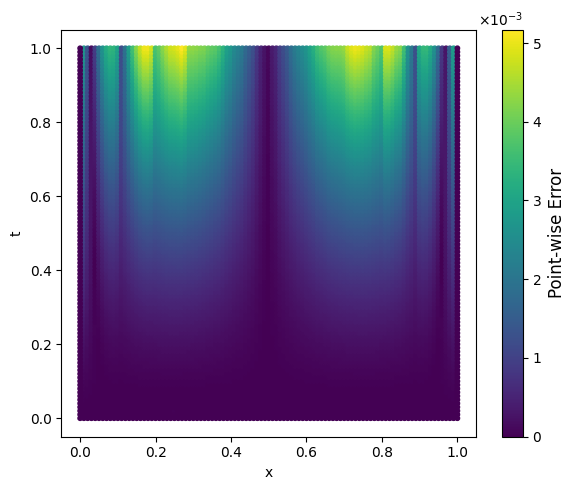

In [4]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(1, hidden_size, 1).to(device) #
Phi.initi()
Phi = Phi.double()

# # ===========================================================
u_func = lambda x, t: 0.9 / (0.04 * np.pi**2) * np.sin(2 * np.pi * x) * (1 - np.exp(-0.04 * np.pi**2 * t))
f_func = lambda x, t: 0.9 * np.sin(2 * np.pi * x) + 0.0 * x * t
g_func = lambda x, t: 0.0 * x * t   # boundary condition
u0_func = lambda x: 0.0 * x 
torchdtype = torch.float64

#####
tau = 1e-2
T = 1 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)     # (Nt, )
Yin = np.linspace(tau,1-tau,Nt-2)[:,None] # (M1,1)
Yb = np.array([[0.0],[1.0]]) # (2, 1)
Y = np.vstack([Yin, Yb])     # (M, 1)
kap = 0.01

# source points
X = Y
M1 = Yin.shape[0]
M = Y.shape[0]

order = 3
K = 20
reg = 1e-13
u_true = u_func(Y,t)


# # ===========================================================
if order == 0:
    U,LBDF1,LBDF2,LI = rfm_fd_solve_heat(kap, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(kap, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)

error = np.abs(U.toarray() - u_true)


print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = relative_l2(U, u_true)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')

Xg, Tg = np.meshgrid(Y, t, indexing='ij')
x = Xg.ravel()
tt = Tg.ravel()
err = error.ravel()

plt.figure(figsize=(6,5))
sc = plt.scatter(x, tt, c=err, cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('t')
plt.tight_layout()
# plt.savefig(f'./result/heat_rfmfd_p={order}_200_error.eps', bbox_inches='tight')
plt.show()


Run Q=1
X.shape 21
21
cond(LI) = 1.0000000001415144
cond(LBDF1) = 1.0000335906569005
cond(LBDF2) = 3.000046606207606
h = 5.000e-02, Relative L2 error = 1.588e-01, 
Run Q=2
X.shape 41
41
cond(LI) = 1.0000000002789637
cond(LBDF1) = 1.0000327957421973
cond(LBDF2) = 3.0000481744077865
h = 2.500e-02, Relative L2 error = 1.589e-01, 
Run Q=3
X.shape 81
81
cond(LI) = 1.000000000579035
cond(LBDF1) = 1.000035642843856
cond(LBDF2) = 3.0000514981123287
h = 1.250e-02, Relative L2 error = 1.592e-01, 
Run Q=4
X.shape 101
101
cond(LI) = 1.0000000007070842
cond(LBDF1) = 1.0000356244540338
cond(LBDF2) = 3.000051508602335
h = 1.000e-02, Relative L2 error = 1.593e-01, 
Run Q=1
X.shape 21
21
cond(LI) = 1.0000000001414977
cond(LBDF1) = 1.0000339591201117
cond(LBDF2) = 3.000035725577299
h = 5.000e-02, Relative L2 error = 1.588e-01, 
Run Q=2
X.shape 41
41
cond(LI) = 1.0000000002790885
cond(LBDF1) = 1.0000339916574161
cond(LBDF2) = 3.000043452138821
h = 2.500e-02, Relative L2 error = 1.589e-01, 
Run Q=3
X.shap

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


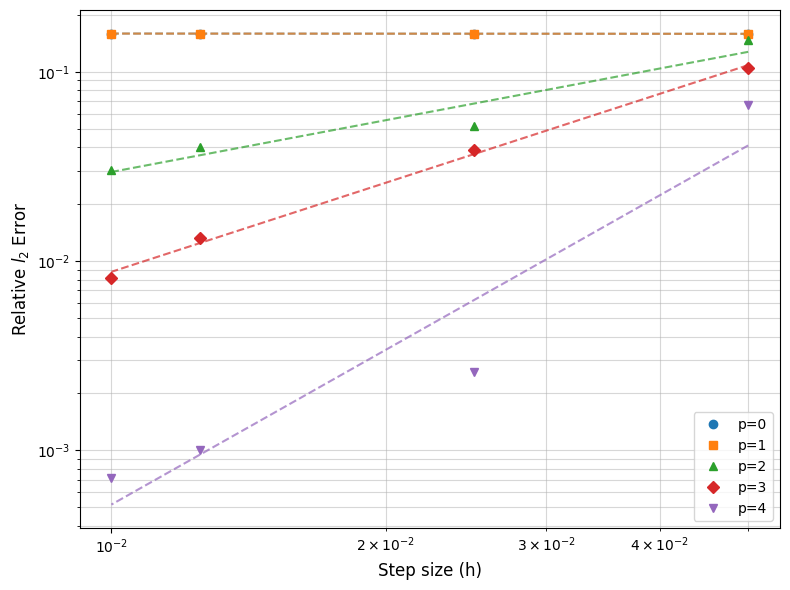

In [5]:
key = 100
np.random.seed(key)
NN = [20, 40, 80, 100]
KK = [20, 20, 25, 25]
H = np.zeros((5,len(NN)))
E = np.zeros((5,len(NN)))
RR = [1e-13,1e-13,1e-13,1e-13,1e-13]

for order in range(5):
    for qi, n_local in enumerate(NN):
        print(f'Run Q={qi+1}')
        X = np.linspace(0,1,n_local+1)[:,None]
        dx = 1/n_local
        Yin = np.linspace(dx,1-dx,n_local-1)[:,None] # (M1,1)
        Yb = np.array([[0.0],[1.0]]) # (2, 1)
        Y = np.vstack([Yin, Yb])     # (M, 1)
        dx = 1/n_local
        Yin = np.linspace(dx,1-dx,n_local-1)[:,None]
        print(f"X.shape",X.shape[0])
        h = fill_distance(X)
        H[order,qi] = h
        reg = RR[qi]
        u_true = u_func(Y,t)
        print(u_true.shape[0])
        K = KK[qi]
        U,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(kap, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
        
        error = np.max(np.abs(U - u_true))
        e = relative_l2(U, u_true)
        E[order,qi] = e
        print(f'h = {h:.3e}, Relative L2 error = {e:.3e}, ')


markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = ['p=0', 'p=1', 'p=2', 'p=3','p=4']
plt.figure(figsize=(8, 6))

for i in range(5):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')
    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)
    # plt.plot(h, e, marker=markers[i], color=colors[i], linestyle='-', label=f'{labels[i]}')

plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
# plt.title('Convergence Study: Least Squares Fit', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./result/heat1d_rfmfd_p=01234_convergence_scatter.eps', bbox_inches='tight')
plt.show()




$Operator learning$

In [6]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve
from scipy.linalg import cholesky, solve_triangular
import time

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 1e-12
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)

def wls_chol_rowmax(A, b, reg=0.0):
    """
    WLS_CHOL_ROWMAX
    Solve weighted least squares using Cholesky factorization
        min_x || W (A x - b) ||_2^2
    where weights w_i = 1 / (max_j |A_ij| + eps)
    Parameters
    ----------
    A : scipy.sparse matrix, shape (M, N)
        Sparse system matrix
    b : ndarray, shape (M,)
        Right-hand side
    reg : float, optional
        Tikhonov regularization parameter (default 0)
    Returns
    -------
    x : ndarray, shape (N,)
        Solution vector
    info : dict
        Diagnostic information
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()

    b = np.asarray(b,dtype=np.float64).squeeze(-1) 
    M, N = A.shape
    assert b.shape[0] == M, "Dimension mismatch"
    # -------------------------------------------------
    # Step 1: row-wise max for sparse matrix
    # -------------------------------------------------
    # Equivalent to MATLAB: full(max(abs(A), [], 2))
    # row_max = np.asarray(np.abs(A).max(axis=1)).ravel()   # (M,) ndarray
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    eps0 = 1e-12
    w = 10 / (row_max + eps0)   # (M,)
    # -------------------------------------------------
    # Step 2: apply weights implicitly
    # -------------------------------------------------
    # Aw = W * A, bw = W * b
    W = sp.diags(w, offsets=0, format='csr')
    Aw = W @ A
    bw = w * b
  
    # -------------------------------------------------
    # Step 3: normal equations
    # -------------------------------------------------
    AtA = Aw.T @ Aw    # (N, N), sparse SPD (hopefully)
    Atb = Aw.T @ bw

    if reg > 0:
        AtA = AtA + reg * sp.eye(N, format='csr')

    # -------------------------------------------------
    # Step 4: Cholesky solve
    # -------------------------------------------------
    try:
        # scipy 对稀疏 Cholesky 没有内建 chol
        # spsolve 等价于 MATLAB 的 "\" 退化路径
        x = spla.spsolve(AtA, Atb)
        flag = 0
    except Exception:
        print("Warning: linear solve failed.")
        x = spla.lsmr(AtA, Atb)[0]
        flag = 1
    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    try:
        cond_est = spla.onenormest(AtA) * spla.onenormest(spla.inv(AtA))
    except Exception:
        cond_est = np.nan

    info = {
        "flag": flag,
        "row_max_min": row_max.min(),
        "row_max_max": row_max.max(),
        "cond_est": cond_est
    }
    return x, info

def rfm_fd_poly_solve_heat(kap, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = order + 1 # number of polynomial basis in 1D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)
    # Construct sparse L matrix
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    LBDF2 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin, t) if callable(f_func) else f_func # (M1,NT)
    g_val = g_func(Yb, t) if callable(g_func) else g_func  # (2, NT)
    u0 = u0_func(Y) if callable(u0_func) else u0_func      # (M,1)
    start_time = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (1,)
        idx_local = idx[i,:]   # (K,)
        Z = X[idx_local]       # (K,1)
        dist_ZZ = np.abs(Z - Z.T)      # (K,K) 
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_xj, dx_phi, d2x_phi = dphi_wrt_y_1d_batch(Phi, y, Z) # (1,K)
        ## AP
        P = poly1D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+Norder)
        AP[K:,:-Norder] = P.T # (Norder,K)
        AP = AP + reg * np.eye(K+Norder)
        LU = lu_factor(AP)
        ## w_ide, w_lap
        p_y = poly1D(y, order) # (1,Norder)
        RHS_ide[:K,0] = phi_xj.reshape(-1,)
        RHS_ide[K:,0] = p_y.reshape(-1,)
        w_ide = lu_solve(LU, RHS_ide).T # (1,K+Norder)
        RHS_lap[:K,0] = d2x_phi.reshape(-1,)
        RHS_lap[K:,0] = lap_poly1D(y,order).reshape(-1,)
        w_lap = lu_solve(LU, RHS_lap).T # (1,K+Noder)
        if i < M1 :
            LBDF1[i,idx_local] = (w_ide[0,:K] - kap * tau * w_lap[0,:K])
            LBDF2[i,idx_local] = (3 * w_ide[0,:K] - 2* kap * tau * w_lap[0,:K])
        else:
            LBDF1[i,idx_local] = w_ide[0,:K]
            LBDF2[i,idx_local] = w_ide[0,:K]
        LI[i,idx_local] = w_ide[0,:K]
        
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    end_time = time.time()
    print("Compiling matrix cost ", end_time-start_time , "seconds")
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr() # 高效矩阵乘法、解线性系统
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M is not equal to N. Please use QR.")
        # ===========================================================
        # M != N : BDF2 + row-max weighted least squares (Cholesky)
        # ===========================================================
        # ---------- BDF1 start ----------
        # alpha_0 已由初值隐式给定：LI * alpha_0 = u0
        reg1 = reg
        alpha_0, info = wls_chol_rowmax(LI, u0, reg)
        print("LI's condition numbers is ", np.sqrt(info["cond_est"]))
        alpha_0 = alpha_0.reshape(-1, 1)
        # print(alpha_0.shape)
        
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]
        RHS = np.vstack([rhs_int, g_val[:, 1:2]])

        alpha_1, _ = wls_chol_rowmax(LBDF1, RHS, reg)
        alpha_1 = alpha_1.reshape(-1, 1)

        U[:M1, 1:2] = LI[:M1, :] @ alpha_1
        U[M1:, 1:2] = g_val[:, 1:2]

        # ---------- fixed row weights from LBDF2 ----------
        row_max = np.abs(LBDF2).max(axis=1).toarray().ravel()
        row_max[row_max == 0.0] = 1.0
        w = 10 / ((row_max + 1e-12) ** 2) # reg = 1e-12
        W = sp.diags(w, offsets=0, shape=(M, M), format="csr")

        # ---------- normal matrix and Cholesky ----------
        AtWA = LBDF2.T @ (W @ LBDF2)
        cond_AtWA_est = spla.onenormest(AtWA) * spla.onenormest(spla.inv(AtWA))
        print("LBDF2's condition numbers is ", np.sqrt(cond_AtWA_est))
        if reg1 > 0:
            AtWA = AtWA + reg1 * sp.eye(N, format="csr")

        # dense Cholesky
        R = cholesky(AtWA.toarray(), lower=False)
        # ---------- BDF2 time stepping ----------
        for i in range(1, NT - 1):
            rhs_int = LI[:M1, :] @ (4 * alpha_1 - alpha_0) \
                      + 2 * tau * f_val[:, i+1:i+2]

            RHS = np.vstack([rhs_int, g_val[:, i+1:i+2]])
            AtWb = LBDF2.T @ (W @ RHS)

            # solve (R^T R) alpha = AtWb
            y = solve_triangular(R.T, AtWb, lower=True)
            alpha_2 = solve_triangular(R, y, lower=False)

            U[:M1, i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:, i+1:i+2] = g_val[:, i+1:i+2]

            alpha_0 = alpha_1
            alpha_1 = alpha_2


    return U,LBDF1,LBDF2,LI


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(0.9225)**2 * x**2) # operator
        output = self.input_layer(x)
        output = torch.sigmoid(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, -0, 0)

Compiling matrix cost  0.0750739574432373 seconds
p = 6; L infity error in u_rfmfd: 4.145e-02
p = 6; Relative L2 error in u_rfmfd: 2.071e-02
Time step 0, Relative L2 error: 0.000e+00
Time step 1, Relative L2 error: 5.033e-03
Time step 2, Relative L2 error: 6.090e-03
Time step 3, Relative L2 error: 6.816e-03
Time step 4, Relative L2 error: 7.304e-03
Time step 5, Relative L2 error: 7.666e-03
Time step 6, Relative L2 error: 7.966e-03
Time step 7, Relative L2 error: 8.236e-03
Time step 8, Relative L2 error: 8.486e-03
Time step 9, Relative L2 error: 8.722e-03
Time step 10, Relative L2 error: 8.943e-03
Time step 11, Relative L2 error: 9.151e-03
Time step 12, Relative L2 error: 9.344e-03
Time step 13, Relative L2 error: 9.524e-03
Time step 14, Relative L2 error: 9.690e-03
Time step 15, Relative L2 error: 9.843e-03
Time step 16, Relative L2 error: 9.984e-03
Time step 17, Relative L2 error: 1.011e-02
Time step 18, Relative L2 error: 1.023e-02
Time step 19, Relative L2 error: 1.034e-02
Time step

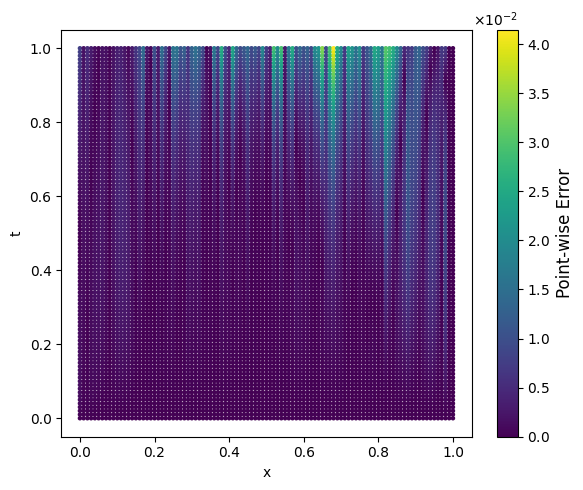

In [7]:
import matplotlib.ticker as ticker

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

tau = 1e-2
T = 1
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

data = loadmat('./data/mydata_heat1d_uniform_sigma2_1e-1.mat')

#'F_0',  'U_0',   'F_new','U_new', 'p','in','bc'
# (M,1), (M,NT),  (M,100), (100,M,NT)
p,F_0,U_0, F_new, U_new, index_in, index_bc = data['p'],data['F_0'],data['U_0'],data['F_new'],data['U_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print("U_new.shape,", F_new.shape) # (n_batch,M,NT)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2

F_new = np.concatenate([F_new[index_in,:],F_new[index_bc,:]],axis=0)
testnum = 0
Yin,Yb = Y[index_in],Y[index_bc] # interior and boundary points

F_new_train = F_new[:M1,testnum]  # (M1,)
F_new_train = F_new_train.repeat(Nt).reshape(M1, Nt)  # (M1,Nt)
# print(f"F_new_train.shape: {F_new_train.shape},{F_new_train}")

# sigma2 = 1
# order = 3
# K = 20

sigma2 = 0.1
order = 6
K = 35

# sigma2 = 1e-2
# order = 3
# K = 20



reg = 1e-12
u_true = U_new[testnum,:,:]
# print(u_true.shape) # (M,NT)
u_true = np.concatenate([u_true[index_in],u_true[index_bc]],axis=0)

# #===========================================================
# #==================== Source points X ====================
# #===========================================================
N = 101
X = np.linspace(0,1,N)[:,None] # (N,1)
# # ===========================================================

if order == 0:
    UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(kap,X, Yin, Yb, t, tau, F_new_train, g_func, u0_func, Phi, K, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(kap, X, Yin, Yb, t, tau, F_new_train, g_func, u0_func, Phi, K, reg, order)

U = U.toarray()
# print("U.shape ",U.shape) #(M,NT)
error = np.abs(U - u_true)
# print(error)
error_inf = np.max(np.max(error))

print(f'p = {order}; L infity error in u_rfmfd: {error_inf:.3e}')
error_l2 = relative_l2(U.ravel(), u_true.ravel())
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_l2:.3e}')

for i in range(Nt):
    err_time = relative_l2(U[:,i], u_true[:,i])
    print(f'Time step {i}, Relative L2 error: {err_time:.3e}')

plt.figure(figsize=(6,5))

yy,tt = np.meshgrid(Y, t, indexing='ij')
tt = tt.ravel()
yy = yy.ravel()
e = error.ravel()

sc = plt.scatter(yy, tt, c = e, cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('t')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()



In [27]:
def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    """

    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)

    W = sp.diags(w, format='csr')

    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)

        if x.ndim == 1:
            x = x[:, None]

        return x

    return solve

def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[0]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin, t) if callable(f_func) else f_func  # (n_batch,M1) or (n_batch,M1,Nt) 
    g_val = g_func(Yb, t) if callable(g_func) else g_func   # (M2, Nt)

    u0 = u0_func(Y) if callable(u0_func) else u0_func       # (M,1) 
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    n_batch = f_val.shape[0]
    if f_val.ndim == 2:
        # (n_batch, M1) 
        time_dependent = False
    else:
        # (n_batch, M1, NT)
        time_dependent = True

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.repeat(n_batch).reshape(n_batch, M)
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            if time_dependent:
                f_slice = f_val[:, :, i + 1]        # (n_batch, M1)
            else:
                f_slice = f_val                     # (n_batch, M1)
            rhs = rhs_int[:M1, :] + tau * f_slice.T   # (M1, n_batch)

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1, _ = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        if time_dependent:
            f_slice = f_val[:, :, 1]        # (n_batch, M1)
        else:
            f_slice = f_val                     # (n_batch, M1)
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_slice.T   # (M1, n_batch)

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):
            if time_dependent:
                f_slice = f_val[:, :, i + 1]        # (n_batch, M1)
            else:
                f_slice = f_val                     # (n_batch, M1)

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_slice.T
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U

    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")

U_new.shape  (100, 101, 101)
After reordering, U_new.shape  (100, 101, 101)
p = 6, inference time: 0.0790 秒
error_L2.shape: (100, 1), error.shape: (100, 101, 101)
p = 6, test on 100 samples. The mean of max error: 3.473299e-02, and mean of relative L2 error: 1.382401e-02
p = 6, test on 100 samples. The variance of max error: 1.859323e-04, and variance of relative L2 error: 3.746536e-05


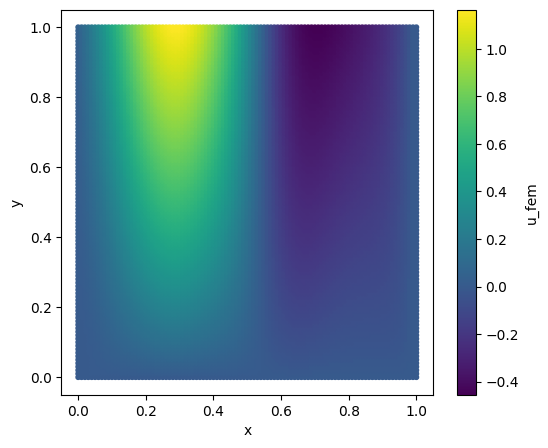

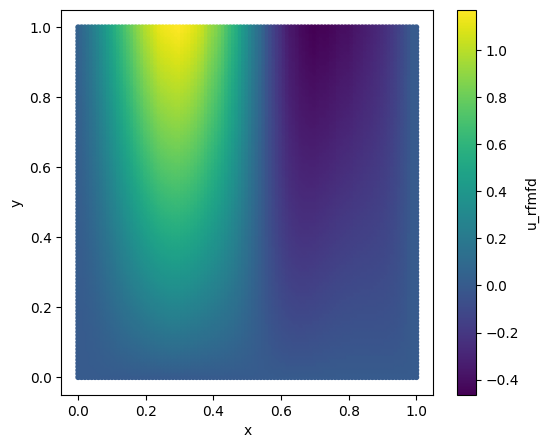

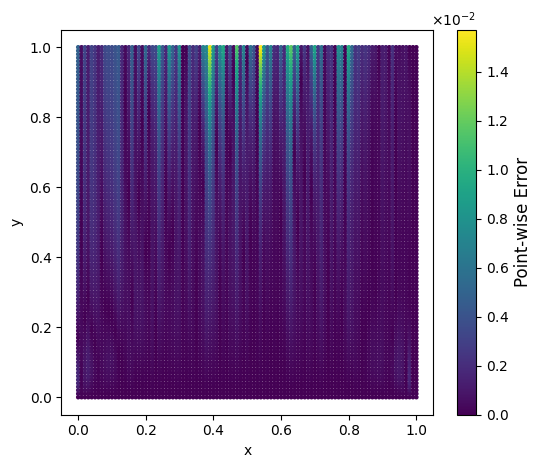

In [28]:
import time

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points

# (M1, n_batch) -> (n_batch,M1,Nt) 
F_new_test = F_new[:M1,:].T  # (100,M1)

u_true = U_new # (100,M,NT)
print( "U_new.shape ", u_true.shape) 
u_true = np.concatenate([u_true[:,index_in,:],u_true[:,index_bc,:]], axis=1)
print("After reordering, U_new.shape ", U_new.shape) #(M,100)


start_time = time.time()
UY = test_solver(LBDF1, LBDF2, LI,
                F_new_test, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2") 

end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")


error = np.abs(UY - u_true) # (n_batch, M, NT)
E_inf =  np.max(np.max(error, axis=2), axis=1) # (n_batch, 1)
error_L2 = (np.linalg.norm(UY - u_true, axis=(1,2)) / np.linalg.norm(u_true, axis=(1,2)))[:, None] # (n_batch, 1)
print(f"error_L2.shape: {error_L2.shape}, error.shape: {error.shape}") #(n_batch,1), (n_batch,M,NT)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

np.random.seed(30)
q = np.random.randint(0, 100)
u_true_q = u_true[q,:,:].ravel()
UY_q = UY[q,:,:].ravel()
error_q = error[q,:,:].ravel()

plt.figure(figsize=(6,5))
plt.scatter(yy, tt, c = u_true_q, cmap='viridis', s=10)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/heat1d_rfmfd_p={order}_u_fem_one_test_sample.eps', bbox_inches='tight')
plt.show()
plt.figure(figsize=(6,5))
plt.scatter(yy, tt, c = UY_q, cmap='viridis', s=10)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/heat1d_rfmfd_p={order}_UY_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(yy, tt, c = error_q, cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Argumented RFM-FD\' point wise error with {order} order polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/heat1d_rfmfd_p={order}_error_one_test_sample.eps', bbox_inches='tight')
plt.show()



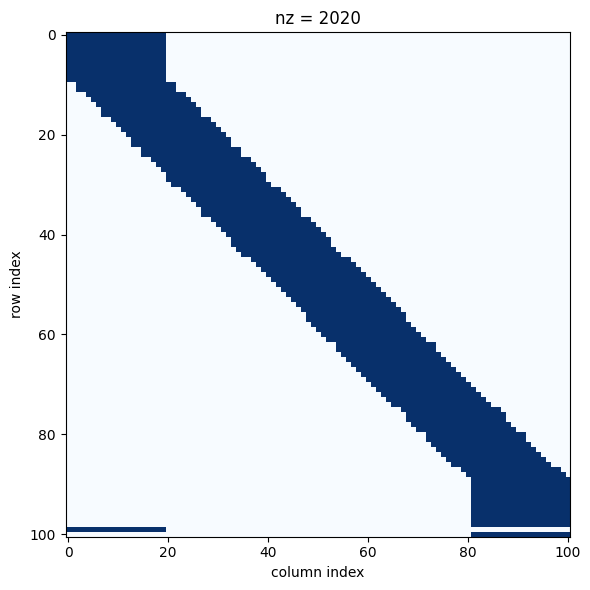

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(LBDF2)

In [9]:
for name, param in Phi.named_parameters():
    print(name, param.data)

input_layer.weight tensor([[ 0.2842],
        [-0.2967],
        [-0.1604],
        [-0.2334],
        [-0.5244],
        [-0.0046],
        [-0.2725],
        [ 0.2287],
        [-0.2161],
        [-0.0757],
        [-0.0685],
        [ 0.0640],
        [ 0.3066],
        [ 0.3625],
        [-0.0834],
        [ 0.0658],
        [ 0.3209],
        [-0.0518],
        [-0.1160],
        [-0.0907],
        [ 0.1197],
        [ 0.0820],
        [-0.0369],
        [ 0.0720],
        [ 0.0468],
        [-0.0157],
        [-0.4444],
        [ 0.1845],
        [-0.0036],
        [ 0.0795],
        [-0.2547],
        [ 0.3697],
        [-0.0387],
        [-0.0531],
        [ 0.0157],
        [-0.1510],
        [ 0.3340],
        [-0.0718],
        [ 0.1586],
        [-0.2193],
        [ 0.1426],
        [-0.0696],
        [ 0.3045],
        [ 0.1889],
        [-0.2389],
        [ 0.2154],
        [-0.2263],
        [-0.0997],
        [ 0.0391],
        [-0.2642]], device='cuda:1', dtype=torch.f